<a href="https://colab.research.google.com/github/mukund1040/Data-Analytics-Projects/blob/main/02-Sales-Data-Analysis/Sales_Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sales Data Analysis

## Project Objective

The objective of this project is to analyze sales data
and identify important sales trends, profitable products,
customer segments, and regional performance.

## Tools Used

- Python
- Pandas
- NumPy
- Matplotlib
- Google Colab..

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
print("Libraries loaded successfully")

Libraries loaded successfully


In [ ]:
import os

for root, dirs, files in os.walk("/"):
    if "Sample - Superstore.csv" in files:
        print(os.path.join(root, "Sample - Superstore.csv"))

/Sample - Superstore.csv


In [ ]:
df = pd.read_csv("/Sample - Superstore.csv" ,  encoding="latin1")

df.head()


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


## 01.Understand the Data

### Find the size of the dataset

In [ ]:
df.shape

(9994, 21)

### all column names

In [ ]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

### Understand data types and missing values

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

### Check missing values

In [ ]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


Check duplicate rows

In [ ]:
df.duplicated().sum()

np.int64(0)

### Basic statistics

In [ ]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


## 02. Understand the business

### total sales.

In [ ]:
df["Sales"].sum()

np.float64(2297200.8603000003)

### total profit.

In [ ]:
df["Profit"].sum()

np.float64(286397.0217)

### total quantity sold.

In [ ]:
df["Quantity"].sum()

np.int64(37873)

### number of unique orders.

In [ ]:
df["Order ID"].nunique()

5009

## 03 Data Cleaning & Date Conversion

Check the current data types

In [ ]:
df.dtypes

,0
Row ID,int64
Order ID,object
Order Date,object
Ship Date,object
Ship Mode,object
Customer ID,object
Customer Name,object
Segment,object
Country,object
City,object


Convert Order Date to datetime

In [ ]:
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Order Date"].dtype

dtype('<M8[ns]')

Convert Ship Date

In [ ]:
df["Ship Date"] = pd.to_datetime(df["Ship Date"])
df[["Order Date", "Ship Date"]].head()

,Order Date,Ship Date
0,2016-11-08,2016-11-11
1,2016-11-08,2016-11-11
2,2016-06-12,2016-06-16
3,2015-10-11,2015-10-18
4,2015-10-11,2015-10-18


## 04 Create useful date columns

Create Year

In [ ]:
df["Year"] = df["Order Date"].dt.year
df["Year"].unique()

array([2016, 2015, 2014, 2017], dtype=int32)

Create Month

In [ ]:
df["Month"] = df["Order Date"].dt.month
df["Month"].unique()

array([11,  6, 10,  4, 12,  5,  8,  7,  9,  1,  3,  2], dtype=int32)

 Create Month Name

In [ ]:
df["Month_Name"] = df["Order Date"].dt.month_name()

In [ ]:
df[["Order Date", "Year", "Month", "Month_Name"]].head()

,Order Date,Year,Month,Month_Name
0,2016-11-08,2016,11,November
1,2016-11-08,2016,11,November
2,2016-06-12,2016,6,June
3,2015-10-11,2015,10,October
4,2015-10-11,2015,10,October


## 05 Calculate shipping time

In [ ]:
df["Shipping_Days"] = (
    df["Ship Date"] - df["Order Date"]
).dt.days

In [ ]:
df[["Order Date", "Ship Date", "Shipping_Days"]].head()

,Order Date,Ship Date,Shipping_Days
0,2016-11-08,2016-11-11,3
1,2016-11-08,2016-11-11,3
2,2016-06-12,2016-06-16,4
3,2015-10-11,2015-10-18,7
4,2015-10-11,2015-10-18,7


## 06 Check whether our new columns are correct

In [ ]:
df[["Year", "Month", "Month_Name", "Shipping_Days"]].describe()

,Year,Month,Shipping_Days
count,9994.000000,9994.000000,9994.000000
mean,2015.722233,7.809686,3.958175
std,1.123555,3.284654,1.747567
min,2014.000000,1.000000,0.000000
25%,2015.000000,5.000000,3.000000
50%,2016.000000,9.000000,4.000000
75%,2017.000000,11.000000,5.000000
max,2017.000000,12.000000,7.000000


In [ ]:
df["Shipping_Days"].min(), df["Shipping_Days"].max()

(0, 7)

## 07 Analyze Sales by Year

Calculate yearly sales

In [ ]:
yearly_sales = df.groupby("Year")["Sales"].sum()

yearly_sales

,Sales
Year,
2014,484247.4981
2015,470532.5090
2016,609205.5980
2017,733215.2552


Visualize yearly sales

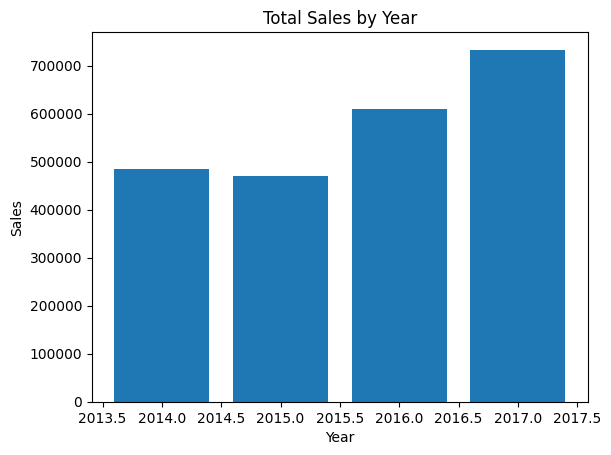

In [ ]:
plt.bar(yearly_sales.index, yearly_sales.values)

plt.title("Total Sales by Year")
plt.xlabel("Year")
plt.ylabel("Sales")

plt.show()

Find the best year

In [ ]:
yearly_sales.idxmax()

np.int32(2017)

the sales amount for that year.

In [ ]:
yearly_sales.max()

733215.2552

## 08 Analyze Sales by Category

In [ ]:
category_sales = df.groupby("Category")["Sales"].sum().sort_values(ascending=False)

category_sales

,Sales
Category,
Technology,836154.0330
Furniture,741999.7953
Office Supplies,719047.0320


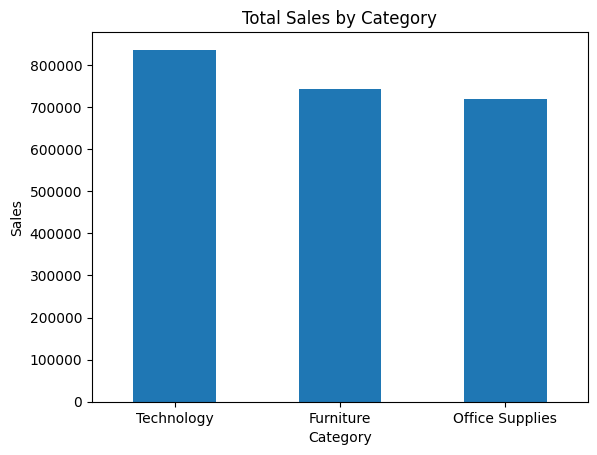

In [ ]:
category_sales.plot(kind="bar")

plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.xticks(rotation=0)
plt.show()

find the best category:

In [ ]:
category_sales.idxmax()

'Technology'

## 09 Analyze Sales by Sub-Category

In [ ]:
subcategory_sales = df.groupby("Sub-Category")["Sales"].sum().sort_values(ascending=False)

subcategory_sales

,Sales
Sub-Category,
Phones,330007.0540
Chairs,328449.1030
Storage,223843.6080
Tables,206965.5320
Binders,203412.7330
Machines,189238.6310
Accessories,167380.3180
Copiers,149528.0300
Bookcases,114879.9963


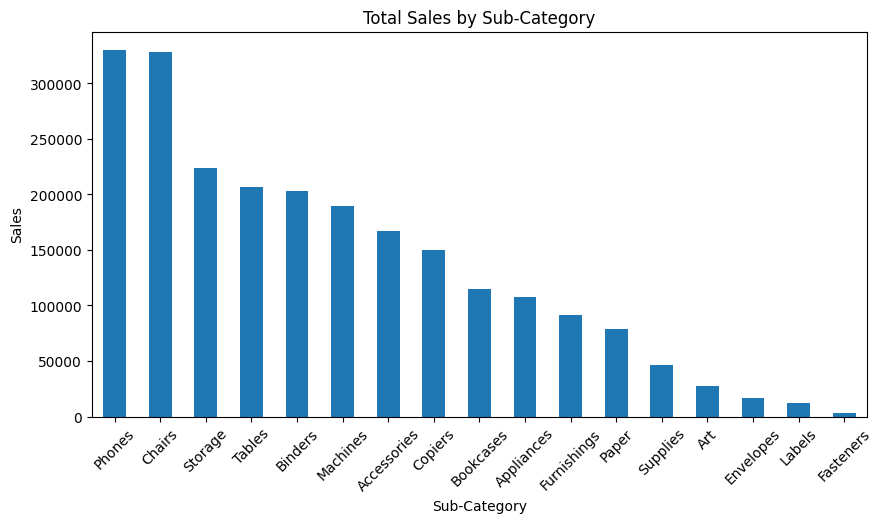

In [ ]:
subcategory_sales.plot(kind="bar", figsize=(10,5))

plt.title("Total Sales by Sub-Category")
plt.xlabel("Sub-Category")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.show()

Find the top sub-category:

In [ ]:
subcategory_sales.idxmax()

'Phones'

## 10 Analyze Sales by Region

Which region generates the most sales?

In [ ]:
region_sales = df.groupby("Region")["Sales"].sum().sort_values(ascending=False)

region_sales

,Sales
Region,
West,725457.8245
East,678781.2400
Central,501239.8908
South,391721.9050


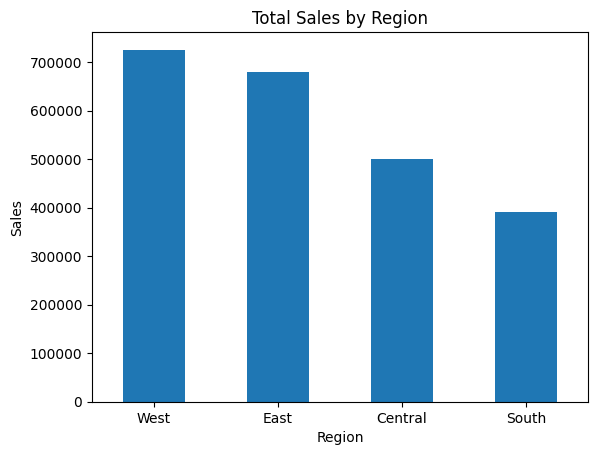

In [ ]:
region_sales.plot(kind="bar")

plt.title("Total Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales")
plt.xticks(rotation=0)
plt.show()

Find the best region:

In [ ]:
region_sales.idxmax()

'West'

## 11 Analyze Profit

Profit by category

In [ ]:
category_profit = df.groupby("Category")["Profit"].sum().sort_values(ascending=False)

category_profit

,Profit
Category,
Technology,145454.9481
Office Supplies,122490.8008
Furniture,18451.2728


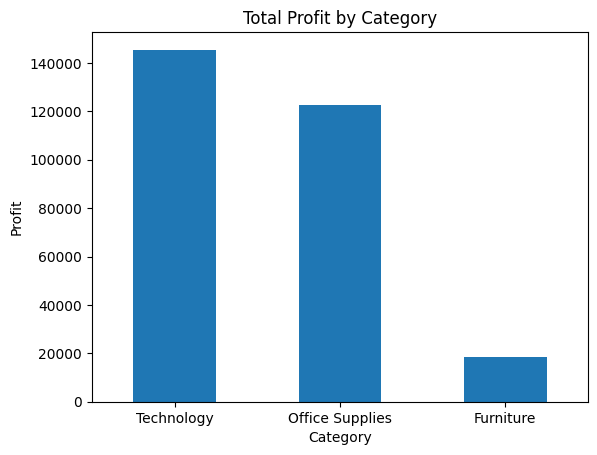

In [ ]:
category_profit.plot(kind="bar")

plt.title("Total Profit by Category")
plt.xlabel("Category")
plt.ylabel("Profit")
plt.xticks(rotation=0)
plt.show()

Find the most profitable category:

In [ ]:
category_profit.idxmax()

'Technology'

## 12 Find the most profitable sub-category

In [ ]:
subcategory_profit = df.groupby("Sub-Category")["Profit"].sum().sort_values(ascending=False)

subcategory_profit

,Profit
Sub-Category,
Copiers,55617.8249
Phones,44515.7306
Accessories,41936.6357
Paper,34053.5693
Binders,30221.7633
Chairs,26590.1663
Storage,21278.8264
Appliances,18138.0054
Furnishings,13059.1436


Find the top one:

In [ ]:
subcategory_profit.idxmax()

'Copiers'

the least profitable:

In [ ]:
subcategory_profit.idxmin()
subcategory_profit.idxmin()

'Tables'

## 13 Monthly Sales Trend

Calculate monthly sales

In [ ]:
monthly_sales = df.groupby(["Year", "Month"])["Sales"].sum()

monthly_sales

Year  Month
2014  1         14236.8950
      2          4519.8920
      3         55691.0090
      4         28295.3450
      5         23648.2870
      6         34595.1276
      7         33946.3930
      8         27909.4685
      9         81777.3508
      10        31453.3930
      11        78628.7167
      12        69545.6205
2015  1         18174.0756
      2         11951.4110
      3         38726.2520
      4         34195.2085
      5         30131.6865
      6         24797.2920
      7         28765.3250
      8         36898.3322
      9         64595.9180
      10        31404.9235
      11        75972.5635
      12        74919.5212
2016  1         18542.4910
      2         22978.8150
      3         51715.8750
      4         38750.0390
      5         56987.7280
      6         40344.5340
      7         39261.9630
      8         31115.3743
      9         73410.0249
      10        59687.7450
      11        79411.9658
      12        96999.0430
2017  1         43971.3740
      2         20301.1334
      3         58872.3528
      4         36521.5361
      5         44261.1102
      6         52981.7257
      7         45264.4160
      8         63120.8880
      9         87866.6520
      10        77776.9232
      11       118447.8250
      12        83829.3188
Name: Sales, dtype: float64

Make a line chart

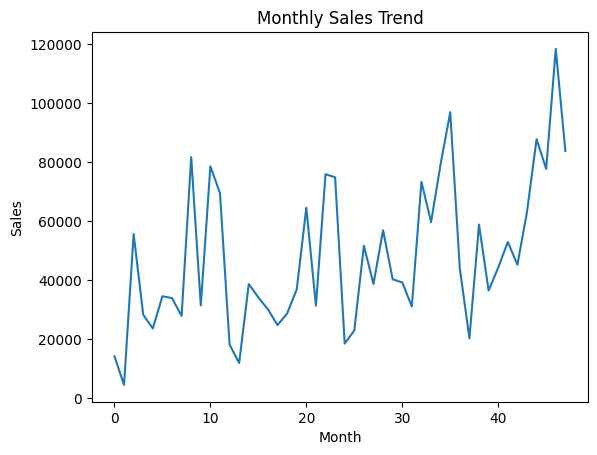

In [ ]:
plt.plot(monthly_sales.values)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.show()

A better version

In [ ]:
df["Year_Month"] = df["Order Date"].dt.to_period("M")

In [ ]:
monthly_sales = df.groupby("Year_Month")["Sales"].sum()
monthly_sales.head()

,Sales
Year_Month,
2014-01,14236.895
2014-02,4519.892
2014-03,55691.009
2014-04,28295.345
2014-05,23648.287


Create the improved chart

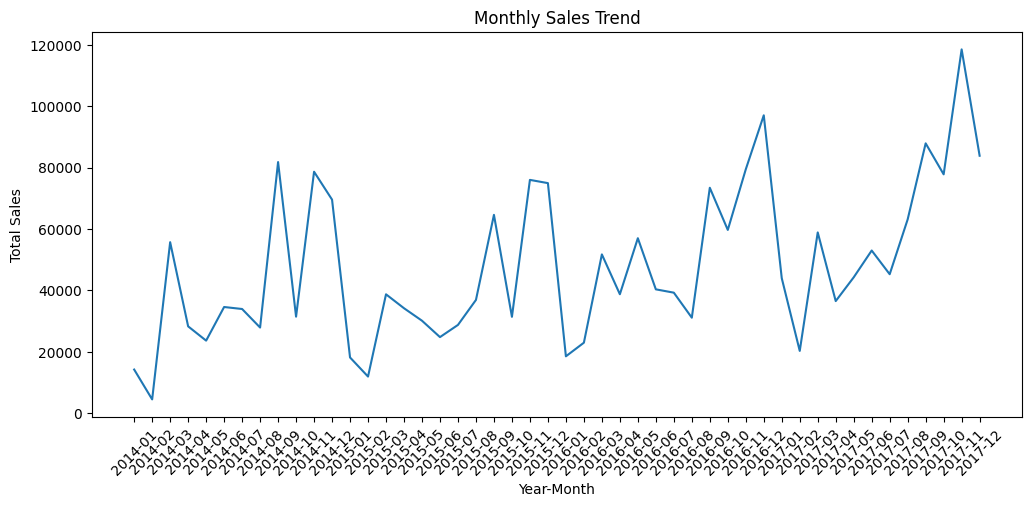

In [ ]:
plt.figure(figsize=(12, 5))

plt.plot(monthly_sales.index.astype(str), monthly_sales.values)

plt.title("Monthly Sales Trend")
plt.xlabel("Year-Month")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)

plt.show()

Find the best sales month

In [ ]:
monthly_sales.idxmax()

Period('2017-11', 'M')

In [ ]:
monthly_sales.max()

118447.825

Find the lowest sales month

In [ ]:
monthly_sales.idxmin()

Period('2014-02', 'M')

In [ ]:
monthly_sales.min()

4519.892

## 14 Customer Analysis

Find the top 10 customers by sales

In [ ]:
customer_sales = df.groupby("Customer Name")["Sales"].sum()

customer_sales = customer_sales.sort_values(ascending=False)

customer_sales.head(10)

,Sales
Customer Name,
Sean Miller,25043.050
Tamara Chand,19052.218
Raymond Buch,15117.339
Tom Ashbrook,14595.620
Adrian Barton,14473.571
Ken Lonsdale,14175.229
Sanjit Chand,14142.334
Hunter Lopez,12873.298
Sanjit Engle,12209.438


Visualize the top 10 customers

In [ ]:
top_customers = customer_sales.head(10)

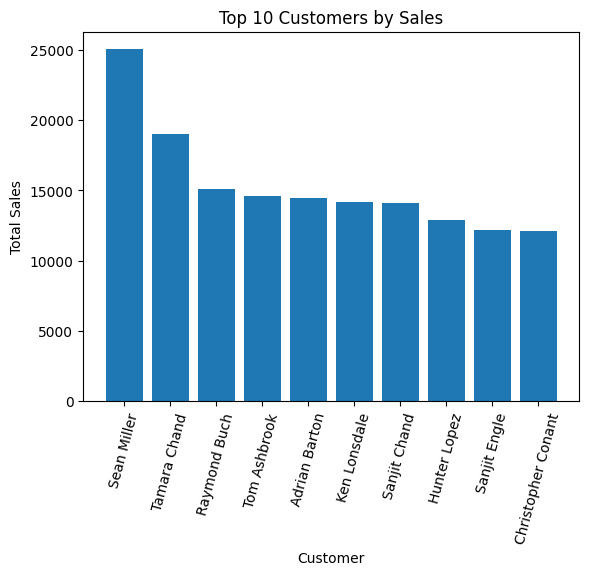

In [ ]:
plt.bar(top_customers.index, top_customers.values)

plt.title("Top 10 Customers by Sales")
plt.xlabel("Customer")
plt.ylabel("Total Sales")

plt.xticks(rotation=75)

plt.show()

Find the most profitable customers

In [ ]:
customer_profit = df.groupby("Customer Name")["Profit"].sum()

customer_profit = customer_profit.sort_values(ascending=False)

customer_profit.head(10)

,Profit
Customer Name,
Tamara Chand,8981.3239
Raymond Buch,6976.0959
Sanjit Chand,5757.4119
Hunter Lopez,5622.4292
Adrian Barton,5444.8055
Tom Ashbrook,4703.7883
Christopher Martinez,3899.8904
Keith Dawkins,3038.6254
Andy Reiter,2884.6208


Compare top sales customer vs top profit customer

In [ ]:
customer_sales.idxmax()

'Sean Miller'

In [ ]:
customer_profit.idxmax()

'Tamara Chand'

## 15 Product Analysis

Sales by sub-category

In [ ]:
subcategory_sales = df.groupby("Sub-Category")["Sales"].sum()

subcategory_sales = subcategory_sales.sort_values(ascending=False)

subcategory_sales

,Sales
Sub-Category,
Phones,330007.0540
Chairs,328449.1030
Storage,223843.6080
Tables,206965.5320
Binders,203412.7330
Machines,189238.6310
Accessories,167380.3180
Copiers,149528.0300
Bookcases,114879.9963


Find the top 5 sub-categories

In [ ]:
top_subcategories = subcategory_sales.head(5)

top_subcategories

,Sales
Sub-Category,
Phones,330007.054
Chairs,328449.103
Storage,223843.608
Tables,206965.532
Binders,203412.733


Create a chart

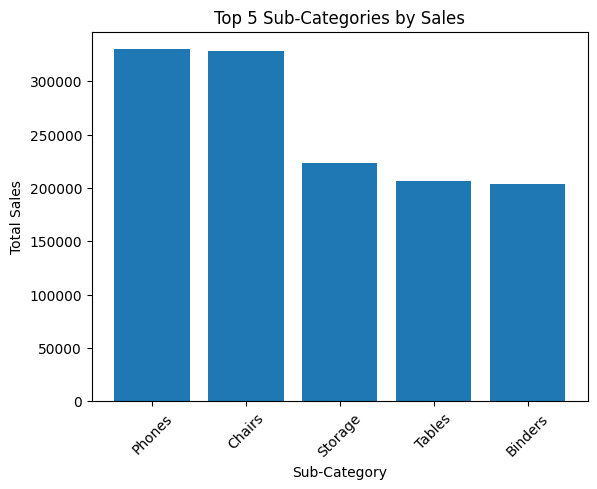

In [ ]:
plt.bar(top_subcategories.index, top_subcategories.values)

plt.title("Top 5 Sub-Categories by Sales")
plt.xlabel("Sub-Category")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)

plt.show()

Find the most profitable sub-category

In [ ]:
subcategory_profit = df.groupby("Sub-Category")["Profit"].sum()

subcategory_profit = subcategory_profit.sort_values(ascending=False)

subcategory_profit

,Profit
Sub-Category,
Copiers,55617.8249
Phones,44515.7306
Accessories,41936.6357
Paper,34053.5693
Binders,30221.7633
Chairs,26590.1663
Storage,21278.8264
Appliances,18138.0054
Furnishings,13059.1436


Find the highest:

In [ ]:
subcategory_profit.idxmax()

'Copiers'

Find the lowest:

In [ ]:
subcategory_profit.idxmin()

'Tables'

Compare sales and profit

In [ ]:
subcategory_summary = df.groupby("Sub-Category")[["Sales", "Profit"]].sum()

subcategory_summary = subcategory_summary.sort_values("Sales", ascending=False)

subcategory_summary

,Sales,Profit
Sub-Category,,
Phones,330007.0540,44515.7306
Chairs,328449.1030,26590.1663
Storage,223843.6080,21278.8264
Tables,206965.5320,-17725.4811
Binders,203412.7330,30221.7633
Machines,189238.6310,3384.7569
Accessories,167380.3180,41936.6357
Copiers,149528.0300,55617.8249
Bookcases,114879.9963,-3472.5560


the highest profit:

In [ ]:
subcategory_profit.idxmax()

'Copiers'

its profit:

In [ ]:
subcategory_profit.max()

55617.8249

## 16 Discount vs Profit 📉

Check the discount values

In [ ]:
df["Discount"].value_counts().sort_index()

,count
Discount,
0.00,4798
0.10,94
0.15,52
0.20,3657
0.30,227
0.32,27
0.40,206
0.45,11
0.50,66


Calculate average profit for each discount level

In [ ]:
discount_profit = df.groupby("Discount")["Profit"].mean()

discount_profit

,Profit
Discount,
0.00,66.900292
0.10,96.055074
0.15,27.288298
0.20,24.702572
0.30,-45.679636
0.32,-88.560656
0.40,-111.927429
0.45,-226.646464
0.50,-310.703456


Create a chart

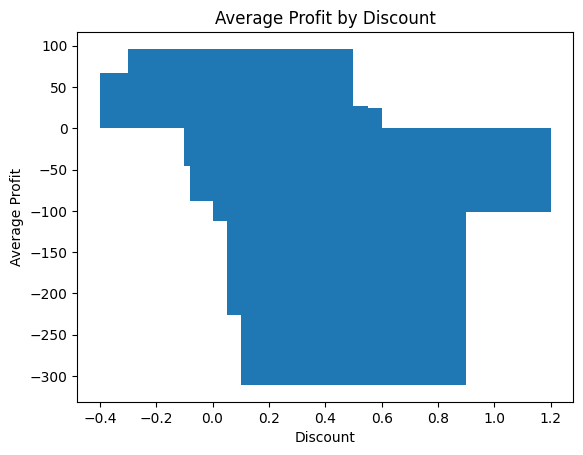

In [ ]:
plt.bar(discount_profit.index, discount_profit.values)

plt.title("Average Profit by Discount")
plt.xlabel("Discount")
plt.ylabel("Average Profit")

plt.show()

Calculate average profit by discount

In [ ]:
discount_summary = df.groupby("Discount").agg(
    Average_Sales=("Sales", "mean"),
    Average_Profit=("Profit", "mean"),
    Total_Profit=("Profit", "sum")
)

discount_summary

,Average_Sales,Average_Profit,Total_Profit
Discount,,,
0.00,226.742074,66.900292,320987.6032
0.10,578.397351,96.055074,9029.1770
0.15,529.971567,27.288298,1418.9915
0.20,209.076940,24.702572,90337.3060
0.30,454.742974,-45.679636,-10369.2774
0.32,536.794770,-88.560656,-2391.1377
0.40,565.134874,-111.927429,-23057.0504
0.45,498.634000,-226.646464,-2493.1111
0.50,892.705152,-310.703456,-20506.4281


Find the discount level with the highest average profit

In [ ]:
discount_profit.idxmax()

np.float64(0.1)

In [ ]:
discount_profit.max()

96.05507446808511

Find the discount level with the lowest average profit

In [ ]:
discount_profit.idxmin()

np.float64(0.5)

In [ ]:
discount_profit.min()

-310.7034560606061

## 17 Shipping Analysis 🚚

### 1 Check average shipping time

In [ ]:
df["Shipping_Days"].mean()

np.float64(3.958174904942966)

### 2 Check minimum and maximum shipping time

In [ ]:
df["Shipping_Days"].min()

0

In [ ]:
df["Shipping_Days"].max()

7

### 3 Shipping time distribution

In [ ]:
shipping_days = df["Shipping_Days"].value_counts().sort_index()

shipping_days

,count
Shipping_Days,
0,519
1,369
2,1334
3,1005
4,2774
5,2169
6,1203
7,621


create a chart

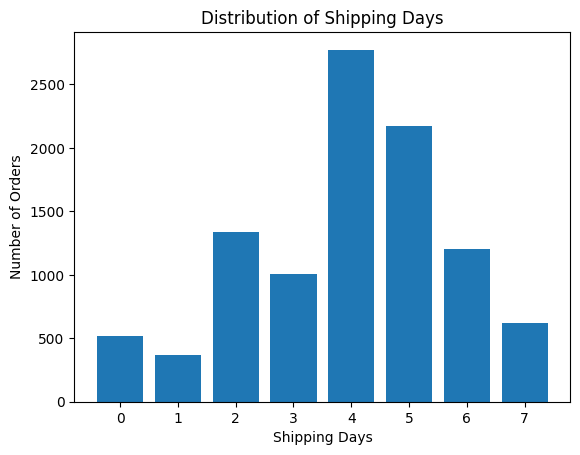

In [ ]:
plt.bar(shipping_days.index, shipping_days.values)

plt.title("Distribution of Shipping Days")
plt.xlabel("Shipping Days")
plt.ylabel("Number of Orders")

plt.show()

### 4 Shipping time by Ship Mode

In [ ]:
df["Ship Mode"].unique()

array(['Second Class', 'Standard Class', 'First Class', 'Same Day'],
      dtype=object)

calculate average shipping time:

In [ ]:
ship_mode_time = df.groupby("Ship Mode")["Shipping_Days"].mean()

ship_mode_time

,Shipping_Days
Ship Mode,
First Class,2.182705
Same Day,0.044199
Second Class,3.238046
Standard Class,5.006535


### 5 Visualize shipping time by Ship Mode

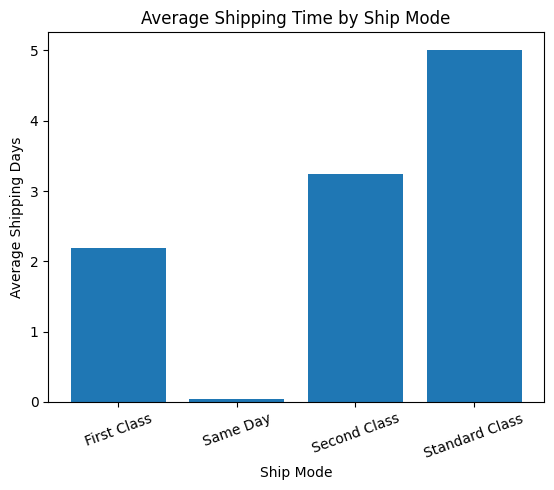

In [ ]:
plt.bar(ship_mode_time.index, ship_mode_time.values)

plt.title("Average Shipping Time by Ship Mode")
plt.xlabel("Ship Mode")
plt.ylabel("Average Shipping Days")

plt.xticks(rotation=20)

plt.show()

### 6 Find the fastest shipping mode

In [ ]:
ship_mode_time.idxmin()

'Same Day'

In [ ]:
ship_mode_time.min()

0.04419889502762431

## 18 Advanced Business Analysis

### 1 Which region is the most profitable?

In [ ]:
region_profit = df.groupby("Region")["Profit"].sum()

region_profit = region_profit.sort_values(ascending=False)

region_profit

,Profit
Region,
West,108418.4489
East,91522.7800
South,46749.4303
Central,39706.3625


Find the most profitable region

In [ ]:
region_profit.idxmax()

'West'

its profit:

In [ ]:
region_profit.max()

108418.4489

Create a chart

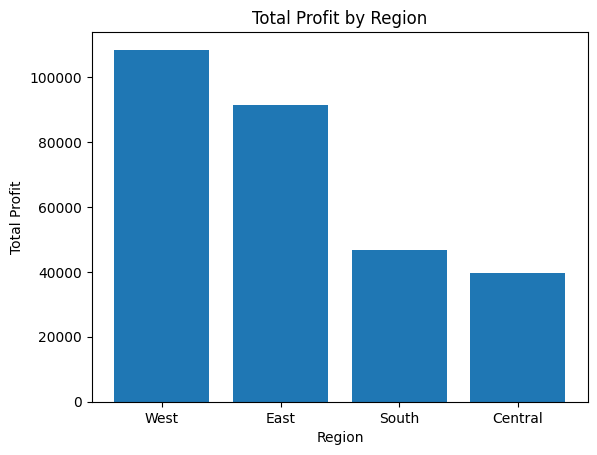

In [ ]:
plt.bar(region_profit.index, region_profit.values)

plt.title("Total Profit by Region")
plt.xlabel("Region")
plt.ylabel("Total Profit")

plt.show()

### 2 — Which category has the best profit margin?

In [ ]:
category_summary = df.groupby("Category")[["Sales", "Profit"]].sum()

category_summary

,Sales,Profit
Category,,
Furniture,741999.7953,18451.2728
Office Supplies,719047.0320,122490.8008
Technology,836154.0330,145454.9481


create the profit margin:
Profit Margin = Profit ÷ Sales × 100

In [ ]:
category_summary["Profit_Margin"] = (
    category_summary["Profit"] / category_summary["Sales"]
) * 100

In [ ]:
category_summary

,Sales,Profit,Profit_Margin
Category,,,
Furniture,741999.7953,18451.2728,2.486695
Office Supplies,719047.0320,122490.8008,17.035158
Technology,836154.0330,145454.9481,17.395712


In [ ]:
category_summary.sort_values("Profit_Margin", ascending=False)

,Sales,Profit,Profit_Margin
Category,,,
Technology,836154.0330,145454.9481,17.395712
Office Supplies,719047.0320,122490.8008,17.035158
Furniture,741999.7953,18451.2728,2.486695


find the category with the highest margin

In [ ]:
category_summary["Profit_Margin"].idxmax()

'Technology'

In [ ]:
category_summary["Profit_Margin"].max()

17.395712076891936

### 3 — Which state generates the most sales?

In [ ]:
state_sales = df.groupby("State")["Sales"].sum()

state_sales = state_sales.sort_values(ascending=False)

state_sales.head(10)

,Sales
State,
California,457687.6315
New York,310876.2710
Texas,170188.0458
Washington,138641.2700
Pennsylvania,116511.9140
Florida,89473.7080
Illinois,80166.1010
Ohio,78258.1360
Michigan,76269.6140


Create a chart:

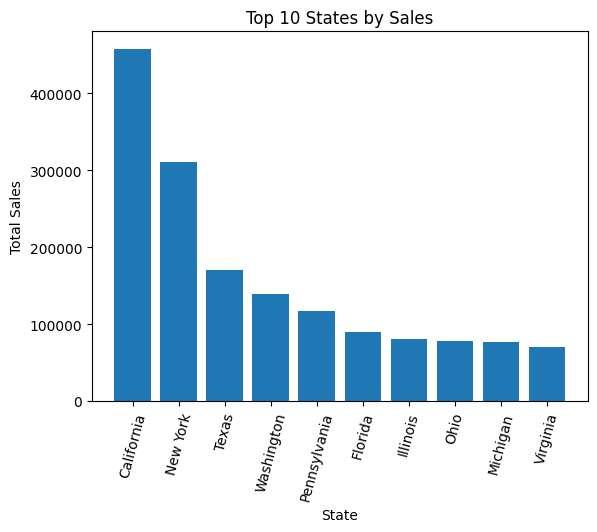

In [ ]:
top_states = state_sales.head(10)

plt.bar(top_states.index, top_states.values)

plt.title("Top 10 States by Sales")
plt.xlabel("State")
plt.ylabel("Total Sales")

plt.xticks(rotation=75)

plt.show()

Find the highest-sales state:

In [ ]:
state_sales.idxmax()

'California'

## 19 Final Visualizations 📊

### 1 — Sales by Year

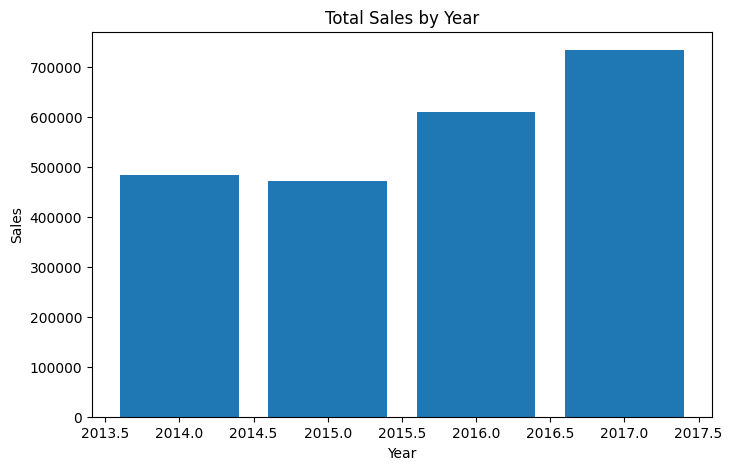

In [ ]:
plt.figure(figsize=(8, 5))

plt.bar(yearly_sales.index, yearly_sales.values)

plt.title("Total Sales by Year")
plt.xlabel("Year")
plt.ylabel("Sales")

plt.show()

### 2 — Sales by Category

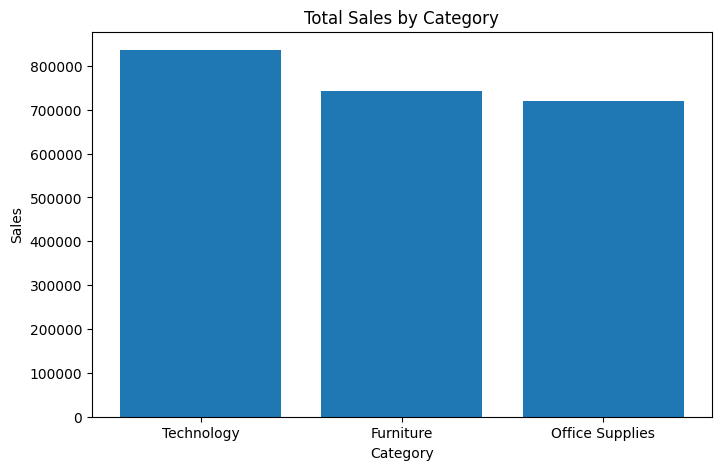

In [ ]:
plt.figure(figsize=(8, 5))

plt.bar(category_sales.index, category_sales.values)

plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")

plt.show()

### 3 — Monthly Sales Trend

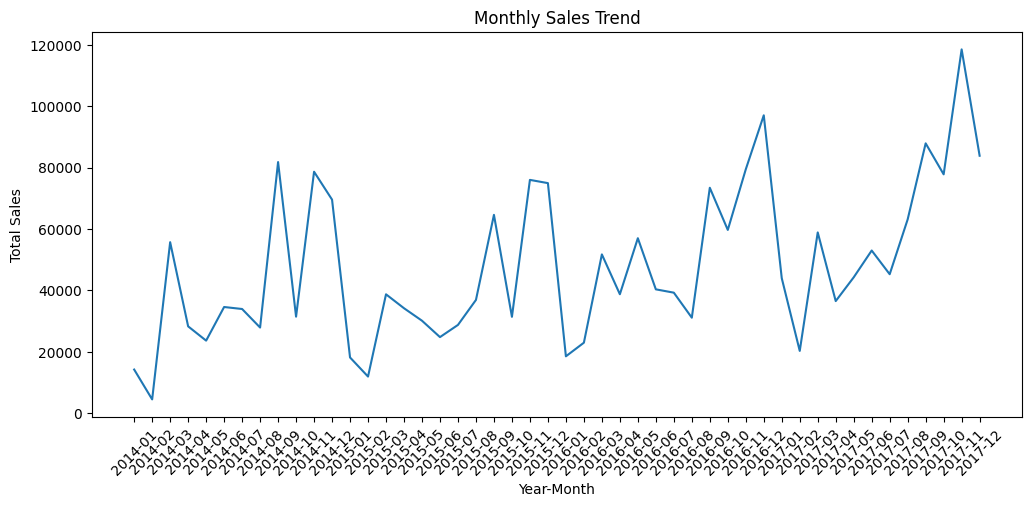

In [ ]:
plt.figure(figsize=(12, 5))

plt.plot(monthly_sales.index.astype(str), monthly_sales.values)

plt.title("Monthly Sales Trend")
plt.xlabel("Year-Month")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)

plt.show()

### 4 — Profit by Category

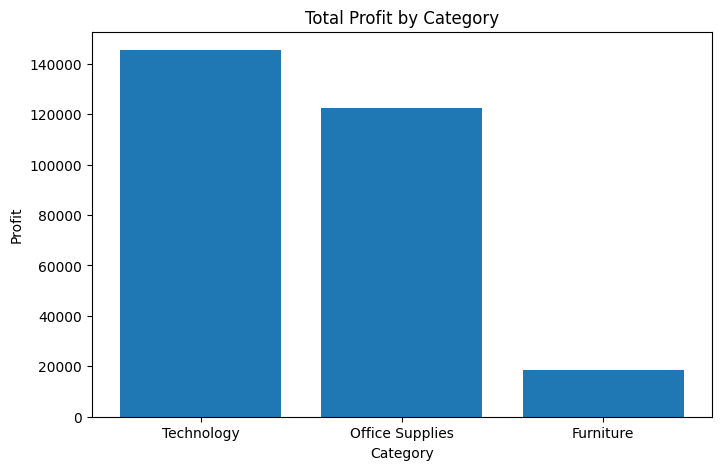

In [ ]:
plt.figure(figsize=(8, 5))

plt.bar(category_profit.index, category_profit.values)

plt.title("Total Profit by Category")
plt.xlabel("Category")
plt.ylabel("Profit")

plt.show()

## 20 — Create a KPI Summary

In [ ]:
total_sales = df["Sales"].sum()

total_profit = df["Profit"].sum()

total_orders = df["Order ID"].nunique()

total_quantity = df["Quantity"].sum()

average_shipping_days = df["Shipping_Days"].mean()

display them:

In [ ]:
print("Total Sales:", total_sales)

print("Total Profit:", total_profit)

print("Total Orders:", total_orders)

print("Total Quantity Sold:", total_quantity)

print("Average Shipping Days:", average_shipping_days)

Total Sales: 2297200.8603000003
Total Profit: 286397.0217
Total Orders: 5009
Total Quantity Sold: 37873
Average Shipping Days: 3.958174904942966


## 21 Key Business Insights

In [ ]:
print("Best Sales Year:", yearly_sales.idxmax())

print("Best Category by Sales:", category_sales.idxmax())

print("Best Category by Profit:", category_profit.idxmax())

print("Most Profitable Region:", region_profit.idxmax())

print("Top Customer by Sales:", customer_sales.idxmax())

print("Highest Profit Discount:", discount_profit.idxmax())

print("Fastest Ship Mode:", ship_mode_time.idxmin())

print("Top Sub-Category by Sales:", subcategory_sales.idxmax())

Best Sales Year: 2017
Best Category by Sales: Technology
Best Category by Profit: Technology
Most Profitable Region: West
Top Customer by Sales: Sean Miller
Highest Profit Discount: 0.1
Fastest Ship Mode: Same Day
Top Sub-Category by Sales: Phones


## Conclusion

This project analyzed sales data using Python, Pandas, NumPy,
and Matplotlib.

The analysis covered sales trends, product categories,
customers, regions, profit, discounts, and shipping performance.

The project helped identify important business patterns and
demonstrated how data can be transformed into meaningful
business insights...........!!!